## **Assignment Natural Language processsing - Sentiment Analysis**

### **Customer Review Classification using Random Forest**

- Dataset consists of 3000 Amazon customer reviews, star ratings, date of review, variant and feedback of various amazon Alexa products like Alexa Echo, Echo dots.
- **The objective is to discover insights into consumer reviews and perfrom sentiment analysis on the data.** Positive or Negative review?
- Dataset: www.kaggle.com/sid321axn/amazon-alexa-reviews also provided(`amazon_alexa.tsv`)
---

**Dataset Information:**

The dataset consists of customer reviews for Amazon Alexa products, including various features related to the product variation, customer rating, and feedback sentiment.

_Features/Columns_:
* rating: The customer rating of the product (scale of 1 to 5).
* date: The date when the review was posted.
* variation: The variation or type of Alexa product the review is for (e.g., "Charcoal Fabric", "Walnut Finish").
* verified_reviews: The actual review text written by the customer.
* feedback: The target variable indicating the sentiment of the review (1 for positive sentiment and 0 for negative sentiment).

In [17]:
# Import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## **1. Dataset Selection and Preprocessing**

In [10]:
# Load the dataset
reviews_data = pd.read_csv(
    "Lesson_10_Customer_Review_Sentiment_Analysis/amazon_alexa.tsv",sep="\t")

# Display the first 5 rows
reviews_data.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


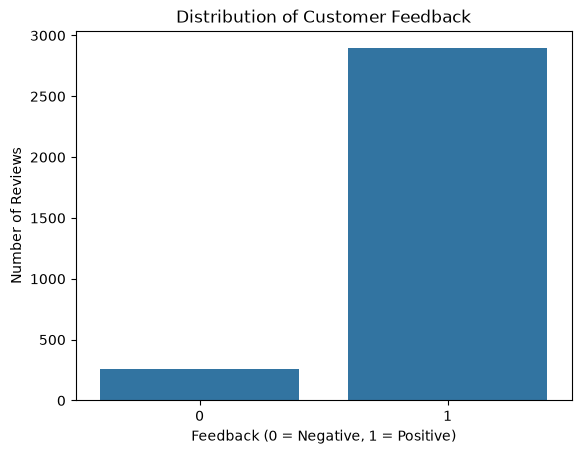

In [11]:
# Visualize the distribution of feedback

sns.countplot(x='feedback', data=reviews_data)

plt.title('Distribution of Customer Feedback')
plt.xlabel('Feedback (0 = Negative, 1 = Positive)')
plt.ylabel('Number of Reviews')

plt.show()


In [13]:
# Distribution of feedback

reviews_data['feedback'].value_counts()

feedback
1    2893
0     257
Name: count, dtype: int64

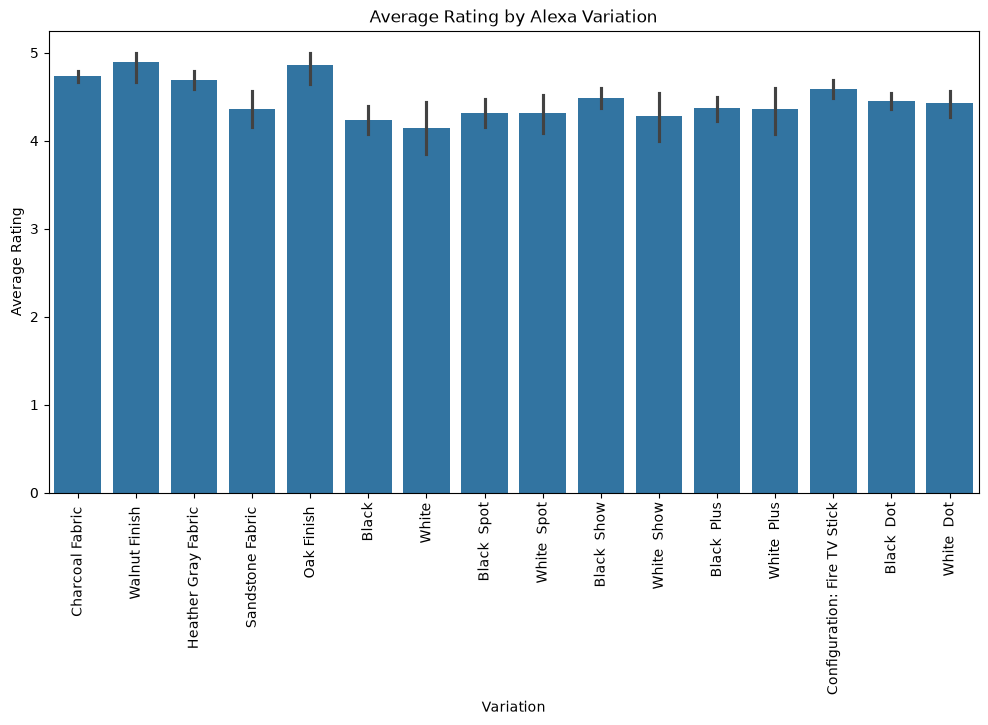

In [14]:
# Visualize the relationship between variations and ratings

plt.figure(figsize=(12, 6))

sns.barplot(x='variation', y='rating', data=reviews_data)

plt.title('Average Rating by Alexa Variation')
plt.xlabel('Variation')
plt.ylabel('Average Rating')
plt.xticks(rotation=90)

plt.show()

In [19]:
# Replace missing reviews with empty text

reviews_data['verified_reviews'] = reviews_data['verified_reviews'].fillna('')

In [ ]:
# Drop irrelevant columns
reviews_data = reviews_data.drop(columns=['date', 'rating'])

# Check the remaining columns
reviews_data.head()

,variation,verified_reviews,feedback
0,Charcoal Fabric,Love my Echo!,1
1,Charcoal Fabric,Loved it!,1
2,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,Charcoal Fabric,Music,1


In [16]:
# One-Hot Encoding for variation column

reviews_data = pd.get_dummies(
    reviews_data,
    columns=['variation'],
    dtype=int)

# Display the result
reviews_data.head()

,verified_reviews,feedback,variation_Black,variation_Black Dot,variation_Black Plus,variation_Black Show,variation_Black Spot,variation_Charcoal Fabric,variation_Configuration: Fire TV Stick,variation_Heather Gray Fabric,variation_Oak Finish,variation_Sandstone Fabric,variation_Walnut Finish,variation_White,variation_White Dot,variation_White Plus,variation_White Show,variation_White Spot
0,Love my Echo!,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,Loved it!,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,"Sometimes while playing a game, you can answer...",1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,I have had a lot of fun with this thing. My 4 ...,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
4,Music,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0


### **2. Feature Engineering**

In [20]:
# Create CountVectorizer
vectorizer = CountVectorizer()

# Tokenize and transform the reviews
reviews_vectorized = vectorizer.fit_transform(
    reviews_data['verified_reviews'])

# Check the shape
print(reviews_vectorized.shape)

(3150, 4044)


In [21]:
# Combine tokenized reviews with the main dataframe

# Convert tokenized reviews to DataFrame
reviews_words = pd.DataFrame(
    reviews_vectorized.toarray(),
    columns=vectorizer.get_feature_names_out())

# Remove the original text column
reviews_data = reviews_data.drop(columns=['verified_reviews'])

# Combine the dataframes
reviews_data = pd.concat(
    [reviews_data.reset_index(drop=True), reviews_words],
    axis=1)

reviews_data.head()

,feedback,variation_Black,variation_Black Dot,variation_Black Plus,variation_Black Show,variation_Black Spot,variation_Charcoal Fabric,variation_Configuration: Fire TV Stick,variation_Heather Gray Fabric,variation_Oak Finish,...,youtube,yr,yrs,yup,zero,zigbee,zonked,zzzz,zzzzzzz,útil
0,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Prepare data for modeling
# TODO: Split the data into features (X) and target (y)
# Hint: The target variable is 'feedback'

In [ ]:


# TODO: Split the data into training and testing sets
# Hint: Use train_test_split from sklearn.model_selection

# Train the Random Forest model
# TODO: Create and train the Random Forest model
# Hint: Use RandomForestClassifier from sklearn.ensemble

# Evaluate the model
# TODO: Generate predictions and create confusion matrix
# Hint: Use the predict() method and confusion_matrix from sklearn.metrics

# TODO: Plot confusion matrix
# Hint: Use seaborn's heatmap function

# TODO: Print classification report
# Hint: Use classification_report from sklearn.metrics

# Feature Importance
# TODO: Visualize feature importance
# Hint: Access feature_importances_ attribute of the trained model

# TODO: Make predictions on new data
# Hint: Create a function that takes a new review text, preprocesses it,
# and uses the trained model to predict its sentiment

# Example usage of your prediction function:
# new_review = "I love my Alexa device! It's so helpful."
# predicted_sentiment = predict_sentiment(new_review)
# print(f"The sentiment of the new review is: {predicted_sentiment}")

In [ ]:
# Task 1: Import Libraries and Dataset

# Hint: You need to import libraries like pandas, numpy, matplotlib, seaborn, etc.
# Don't forget to mount Google Drive and load the CSV file using pandas.
# Use `pd.read_csv()` to load the data into a pandas DataFrame.

# TODO: Import necessary libraries

# TODO: Mount Google Drive

# TODO: Load the dataset into a DataFrame and preview the first few rows.


# Hint: Use `sns.countplot()` to visualize the feedback distribution and a bar plot to compare variations and feedback.
# Drop the columns 'date' and 'rating' as they are not relevant for the analysis.

# TODO: Visualize the distribution of feedback (positive/negative)

# TODO: Visualize the relationship between product variation and feedback

# TODO: Drop irrelevant columns ('date', 'rating')



# Hint: Use `pd.get_dummies()` to create one-hot encoded columns for 'variation'.
# Then, concatenate these encoded columns back to the original DataFrame and drop the 'variation' column.

# TODO: Perform one-hot encoding on the 'variation' column




# Hint: Use `CountVectorizer` to tokenize the text data and convert it into numerical representation.
# After transforming the text, drop the 'verified_reviews' column and concatenate the numerical data with the rest of the DataFrame.

# TODO: Tokenize the 'verified_reviews' column using CountVectorizer






# Hint: Use `train_test_split()` to split the data into training and testing sets.
# You need to specify `test_size=0.2` to reserve 20% of the data for testing.

# TODO: Split the data into training and testing sets




# Hint: Initialize a `RandomForestClassifier` with 100 estimators.
# Use the `fit()` method to train the model on the training data.

# TODO: Define and train a Random Forest Classifier





# Hint: Use the `predict()` method to generate predictions for the test data.
# Use `confusion_matrix()` to create the confusion matrix and visualize it using a heatmap.
# Print out a `classification_report()` to evaluate the model's precision, recall, and F1 score.

# TODO: Generate predictions and evaluate the model's performance using a confusion matrix and classification report



# Task 8: Analyze Model Performance
# Hint: Use the `score()` method to calculate accuracy for both training and test sets.
# Compare the results and discuss if the model is overfitting or underfitting.

# TODO: Compare training and testing accuracy and discuss model performance
